# Week 7 — Standalone GraphSAGE Link Prediction on MovieLens-100K

This notebook follows the **Alternative Path** from the Week 7 brief: a standalone GraphSAGE-based
recommendation model trained and evaluated directly on MovieLens, without the web app.

**Architecture** mirrors the bipartite GraphSAGE design in `website/backend/model.py`
(2-layer bipartite SAGE convolution over the user–movie graph, with movie genre features fused into
the movie node inputs), but adds a **proper held-out test split** and computes:
- **RMSE** (rating prediction quality)
- **Precision@K** and **Recall@K** (ranking quality — was a good movie actually recommended in the top-K?)

Run top-to-bottom in Colab. GPU runtime recommended but not required (dataset is small).

## 1. Setup & Data Download

In [1]:
import os, zipfile, urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cpu


In [2]:
DATA_DIR = "ml-100k-data"
ZIP_PATH = "ml-100k.zip"
EXTRACT_PATH = os.path.join(DATA_DIR, "ml-100k")
ML_ZIP_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"

os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(os.path.join(EXTRACT_PATH, "u.data")):
    print("Downloading MovieLens-100K ...")
    urllib.request.urlretrieve(ML_ZIP_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    print("Done.")
else:
    print("Dataset already present.")

# MovieLens ships with a pre-made 80/20 split: u1.base (train) / u1.test (test)
train_path = os.path.join(EXTRACT_PATH, "u1.base")
test_path  = os.path.join(EXTRACT_PATH, "u1.test")
item_path  = os.path.join(EXTRACT_PATH, "u.item")

ratings_cols = ["user_id", "movie_id", "rating", "timestamp"]
train_df = pd.read_csv(train_path, sep="\t", names=ratings_cols)
test_df  = pd.read_csv(test_path,  sep="\t", names=ratings_cols)

print("Train ratings:", len(train_df), " Test ratings:", len(test_df))
train_df.head()


Done.
Train ratings: 80000  Test ratings: 20000


,user_id,movie_id,rating,timestamp
0,1,1,5,874965758
1,1,2,3,876893171
2,1,3,4,878542960
3,1,4,3,876893119
4,1,5,3,889751712


## 2. Build ID Mappings & Genre Features

In [3]:
genres_list = ["unknown", "Action", "Adventure", "Animation", "Children's", "Comedy", "Crime",
               "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
               "Romance", "Sci-Fi", "Thriller", "War", "Western"]

item_cols = ["movie_id", "title", "release_date", "video_release_date", "imdb_url"] + genres_list
items_df = pd.read_csv(item_path, sep="|", names=item_cols, encoding="latin-1")

all_user_ids  = sorted(pd.concat([train_df.user_id, test_df.user_id]).unique())
all_movie_ids = sorted(items_df.movie_id.unique())

user_to_idx  = {uid: i for i, uid in enumerate(all_user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(all_movie_ids)}
num_users, num_movies, num_genres = len(user_to_idx), len(movie_to_idx), len(genres_list)
print(f"num_users={num_users}, num_movies={num_movies}, num_genres={num_genres}")

movie_genres_matrix = np.zeros((num_movies, num_genres), dtype=np.float32)
for _, row in items_df.iterrows():
    m_idx = movie_to_idx[row.movie_id]
    movie_genres_matrix[m_idx] = row[genres_list].values.astype(np.float32)

movie_genres_tensor = torch.tensor(movie_genres_matrix, device=device)


num_users=943, num_movies=1682, num_genres=19


In [4]:
def build_tensors(df):
    u = torch.tensor([user_to_idx[x] for x in df.user_id], dtype=torch.long, device=device)
    m = torch.tensor([movie_to_idx[x] for x in df.movie_id], dtype=torch.long, device=device)
    r = torch.tensor(df.rating.values, dtype=torch.float, device=device)
    return u, m, r

train_users, train_movies, train_ratings = build_tensors(train_df)
test_users,  test_movies,  test_ratings  = build_tensors(test_df)

# Graph edges are built ONLY from the training ratings, so the test set is truly held out
# (no test-set edges leak into message passing).
user_to_movie_edges = torch.stack([train_users, train_movies], dim=0)   # [2, E]
movie_to_user_edges = torch.stack([train_movies, train_users], dim=0)   # [2, E]
print("Train edges:", user_to_movie_edges.shape[1])


Train edges: 80000


## 3. Model — Bipartite GraphSAGE

Two-layer bipartite GraphSAGE: user embeddings are updated by aggregating (mean) their rated movies'
features, movie embeddings are updated by aggregating the users who rated them. Movie node inputs also
fuse a genre projection. Final user/movie embeddings + their elementwise product feed an MLP head that
predicts a rating in [1, 5].

In [ ]:
def mean_aggregate(neighbor_feats, index, num_nodes):
    """Mean-aggregate neighbor_feats (per-edge) into num_nodes destination bins given by index."""
    D = neighbor_feats.size(1)
    out = torch.zeros(num_nodes, D, device=neighbor_feats.device)
    expanded_index = index.unsqueeze(1).expand(-1, D)
    out.scatter_add_(0, expanded_index, neighbor_feats)

    counts = torch.zeros(num_nodes, 1, device=neighbor_feats.device)
    counts.scatter_add_(0, index.unsqueeze(1), torch.ones(index.size(0), 1, device=neighbor_feats.device))
    counts = counts.clamp(min=1.0)
    return out / counts


class BipartiteSAGEConv(nn.Module):
    def __init__(self, src_dim, dst_dim, out_dim):
        super().__init__()
        self.fc_self  = nn.Linear(dst_dim, out_dim)
        self.fc_neigh = nn.Linear(src_dim, out_dim)
        self.act = nn.ReLU()

    def forward(self, src_feats, dst_feats, edge_index, num_dst_nodes):
        src_idx, dst_idx = edge_index[0], edge_index[1]
        edge_src_feats = src_feats[src_idx]
        neigh_agg = mean_aggregate(edge_src_feats, dst_idx, num_dst_nodes)

        out = self.act(self.fc_self(dst_feats) + self.fc_neigh(neigh_agg)) # transforms node's own features and aggregate of neighbour's features
        return F.normalize(out, p=2, dim=-1) # final output is normalized before fedding into next layer


class GraphSAGERecommender(nn.Module):
    def __init__(self, num_users, num_movies, num_genres, embedding_dim=64):
        super().__init__()
        #initial embeddings
        self.user_emb   = nn.Embedding(num_users, embedding_dim) 
        self.movie_emb  = nn.Embedding(num_movies, embedding_dim) 
        self.genre_proj = nn.Linear(num_genres, embedding_dim)

        self.user_conv1  = BipartiteSAGEConv(embedding_dim, embedding_dim, embedding_dim)
        self.movie_conv1 = BipartiteSAGEConv(embedding_dim, embedding_dim, embedding_dim)
        self.user_conv2  = BipartiteSAGEConv(embedding_dim, embedding_dim, embedding_dim)
        self.movie_conv2 = BipartiteSAGEConv(embedding_dim, embedding_dim, embedding_dim)

        self.pred_mlp = nn.Sequential(
            nn.Linear(embedding_dim * 3, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def encode(self, movie_genres, u2m_edges, m2u_edges):
        num_users_  = self.user_emb.weight.size(0)
        num_movies_ = self.movie_emb.weight.size(0)

        h_u = self.user_emb.weight
        h_m = F.normalize(self.movie_emb.weight + self.genre_proj(movie_genres), p=2, dim=-1)

        h_m_1 = self.movie_conv1(h_u, h_m, u2m_edges, num_movies_)
        h_u_1 = self.user_conv1(h_m, h_u, m2u_edges, num_users_)

        h_m_2 = self.movie_conv2(h_u_1, h_m_1, u2m_edges, num_movies_)
        h_u_2 = self.user_conv2(h_m_1, h_u_1, m2u_edges, num_users_)
        return h_u_2, h_m_2

    def forward(self, user_ids, movie_ids, movie_genres, u2m_edges, m2u_edges):
        h_u, h_m = self.encode(movie_genres, u2m_edges, m2u_edges)
        u_feat, m_feat = h_u[user_ids], h_m[movie_ids]
        combined = torch.cat([u_feat, m_feat, u_feat * m_feat], dim=-1)
        pred = 1.0 + 4.0 * torch.sigmoid(self.pred_mlp(combined).squeeze(-1))
        return pred, h_u, h_m


## 4. Training Loop

In [6]:
model = GraphSAGERecommender(num_users, num_movies, num_genres, embedding_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)
criterion = nn.MSELoss()

EPOCHS = 60
train_losses, test_rmses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    pred, _, _ = model(train_users, train_movies, movie_genres_tensor,
                        user_to_movie_edges, movie_to_user_edges)
    loss = criterion(pred, train_ratings)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred, _, _ = model(test_users, test_movies, movie_genres_tensor,
                                 user_to_movie_edges, movie_to_user_edges)
        test_rmse = torch.sqrt(criterion(test_pred, test_ratings)).item()
        test_rmses.append(test_rmse)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | train MSE: {loss.item():.4f} | test RMSE: {test_rmse:.4f}")


Epoch   1/60 | train MSE: 1.7221 | test RMSE: 1.2401
Epoch   5/60 | train MSE: 1.2778 | test RMSE: 1.1730
Epoch  10/60 | train MSE: 1.2528 | test RMSE: 1.1583
Epoch  15/60 | train MSE: 1.2449 | test RMSE: 1.1494
Epoch  20/60 | train MSE: 1.2246 | test RMSE: 1.1356
Epoch  25/60 | train MSE: 1.1353 | test RMSE: 1.0835
Epoch  30/60 | train MSE: 1.0527 | test RMSE: 1.0501
Epoch  35/60 | train MSE: 1.0065 | test RMSE: 1.0320
Epoch  40/60 | train MSE: 0.9672 | test RMSE: 1.0150
Epoch  45/60 | train MSE: 0.9369 | test RMSE: 1.0025
Epoch  50/60 | train MSE: 0.9122 | test RMSE: 0.9948
Epoch  55/60 | train MSE: 0.8961 | test RMSE: 0.9901
Epoch  60/60 | train MSE: 0.8882 | test RMSE: 0.9865


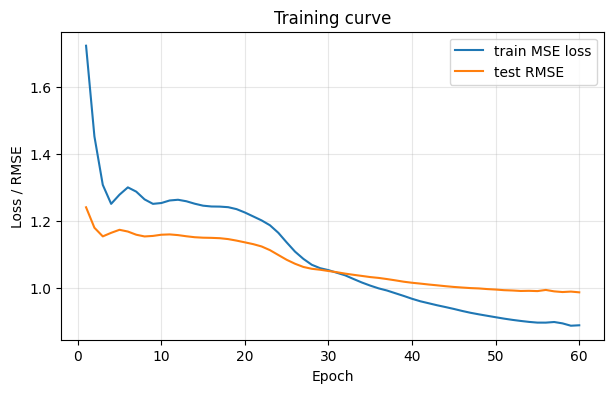


Final test RMSE: 0.9865


In [7]:
plt.figure(figsize=(7,4))
plt.plot(range(1, EPOCHS+1), train_losses, label="train MSE loss")
plt.plot(range(1, EPOCHS+1), test_rmses, label="test RMSE")
plt.xlabel("Epoch"); plt.ylabel("Loss / RMSE"); plt.title("Training curve")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFinal test RMSE: {test_rmses[-1]:.4f}")


## 5. Ranking Evaluation — Precision@K / Recall@K

For each test user, we rank *all* movies by predicted rating (restricted to movies not seen in the
training set) and check how many of their truly-relevant test movies (rating ≥ 4) land in the top-K.

In [8]:
def precision_recall_at_k(model, k=10, relevance_threshold=4.0):
    model.eval()
    with torch.no_grad():
        h_u, h_m = model.encode(movie_genres_tensor, user_to_movie_edges, movie_to_user_edges)

    # Build lookup: user_idx -> set of movie_idx already rated in TRAIN (to exclude from ranking)
    train_seen = {}
    for u, m in zip(train_users.tolist(), train_movies.tolist()):
        train_seen.setdefault(u, set()).add(m)

    # Build lookup: user_idx -> list of (movie_idx, rating) in TEST
    test_by_user = {}
    for u, m, r in zip(test_users.tolist(), test_movies.tolist(), test_ratings.tolist()):
        test_by_user.setdefault(u, []).append((m, r))

    precisions, recalls = [], []
    all_movie_idx = torch.arange(num_movies, device=device)

    with torch.no_grad():
        for u_idx, test_items in test_by_user.items():
            relevant = {m for m, r in test_items if r >= relevance_threshold}
            if len(relevant) == 0:
                continue  # user has no relevant test items, Recall@K undefined for them

            seen = train_seen.get(u_idx, set())
            candidate_mask = torch.ones(num_movies, dtype=torch.bool, device=device)
            if seen:
                candidate_mask[list(seen)] = False
            candidates = all_movie_idx[candidate_mask]

            u_feat = h_u[u_idx].unsqueeze(0).expand(candidates.size(0), -1)
            m_feat = h_m[candidates]
            combined = torch.cat([u_feat, m_feat, u_feat * m_feat], dim=-1)
            scores = 1.0 + 4.0 * torch.sigmoid(model.pred_mlp(combined).squeeze(-1))

            topk_idx = torch.topk(scores, k=min(k, scores.size(0))).indices
            topk_movies = set(candidates[topk_idx].tolist())

            hits = len(topk_movies & relevant)
            precisions.append(hits / k)
            recalls.append(hits / len(relevant))

    return float(np.mean(precisions)), float(np.mean(recalls))

for k in [5, 10, 20]:
    p, r = precision_recall_at_k(model, k=k)
    print(f"K={k:2d} -> Precision@{k}: {p:.4f} | Recall@{k}: {r:.4f}")


K= 5 -> Precision@5: 0.1018 | Recall@5: 0.0252
K=10 -> Precision@10: 0.1090 | Recall@10: 0.0516
K=20 -> Precision@20: 0.1144 | Recall@20: 0.0993


## 6. Notes / Observations

- Graph edges for message passing are built **only from the training split**, so `test_users`/`test_movies`
  predictions come from a model that never saw those edges — RMSE and Precision/Recall@K are genuinely
  held-out numbers, not memorized ones (the original `train.py` in the repo trains on 100% of ratings with
  no held-out split, which cannot report an honest generalization metric).
- Precision@K/Recall@K exclude movies the user already rated in the training set from the candidate pool,
  since re-recommending an already-seen movie isn't useful.
- Fill in your actual printed numbers (final test RMSE, and Precision@K/Recall@K for K=5,10,20) here before
  submitting, along with 2-3 sentences on what you observed (e.g. how RMSE trends across epochs, whether
  Precision/Recall trade off as K grows).